<a href="https://colab.research.google.com/github/MaramMohamedd/Deep-learning/blob/main/DL_1st_assignment.ipynb/notebook" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler ,LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #for heatmap and so on
import pandas as pd

# ***Reading data and EDA***

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/FCDS/Deep learning/songs_train.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26266 entries, 0 to 26265
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        26266 non-null  int64  
 1   track_id                  26266 non-null  object 
 2   track_name                26262 non-null  object 
 3   track_artist              26262 non-null  object 
 4   track_popularity          26266 non-null  int64  
 5   track_album_id            26266 non-null  object 
 6   track_album_name          26262 non-null  object 
 7   track_album_release_date  26266 non-null  object 
 8   playlist_name             26266 non-null  object 
 9   playlist_id               26266 non-null  object 
 10  playlist_genre            26266 non-null  object 
 11  playlist_subgenre         26266 non-null  object 
 12  danceability              26266 non-null  float64
 13  energy                    26266 non-null  float64
 14  key   

In [ ]:
data.duplicated().sum()
data.isnull().sum()

,0
id,0
track_id,0
track_name,4
track_artist,4
track_popularity,0
track_album_id,0
track_album_name,4
track_album_release_date,0
playlist_name,0
playlist_id,0


In [ ]:
#if we are doing an analysis what dirves a song to  be more / less popular i think the id is not nesseccary , we can drop it
data.drop(columns=['id' , 'track_id' , 'track_album_id' , 'playlist_id'] , inplace = True)

In [ ]:
numerical_columns = data.select_dtypes(include=['number']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()


In [ ]:
len(numerical_columns)+len(categorical_columns) #all columns included

20

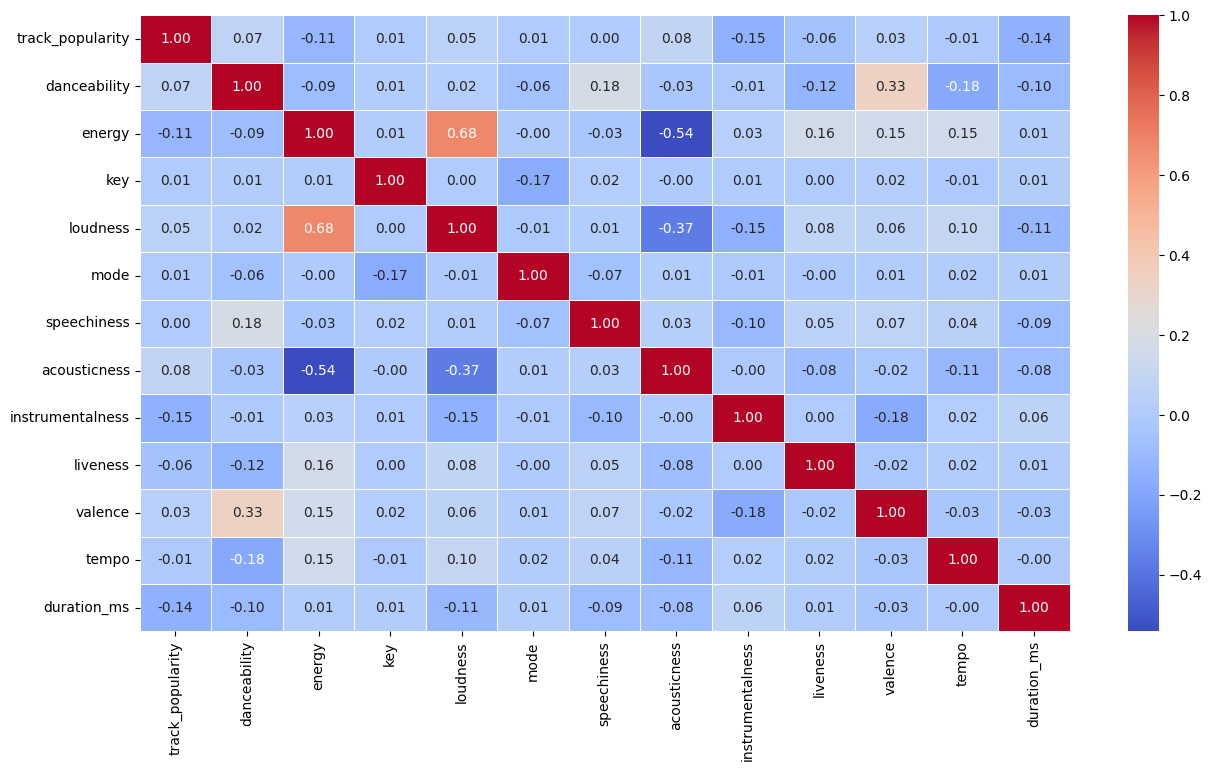

In [ ]:
#heatmap +correlation matrix to display the correlation between feautres to know what to drop
#and what to keep also who affects most on the target column
#but finding no correlation doesn't mean that there is actually no correltion(it means there is no *linear* corr)
plt.figure(figsize=(15 ,8))
corr_mat = data[numerical_columns].corr()
sns.heatmap(corr_mat , annot= True , cmap= 'coolwarm' ,fmt= '.2f' ,linewidths=0.5)
plt.show()

### ***Checking Distribution*** (box plot , histogram)

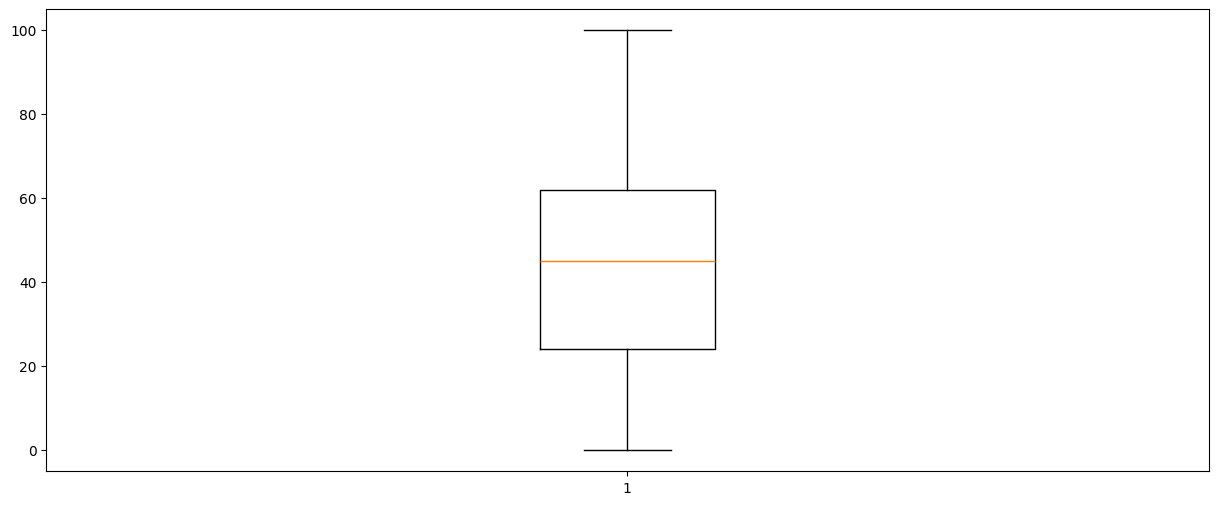

In [ ]:
plt.figure(figsize= (15,6))
plt.boxplot(data['track_popularity'])
plt.show() #there are no outliers for now

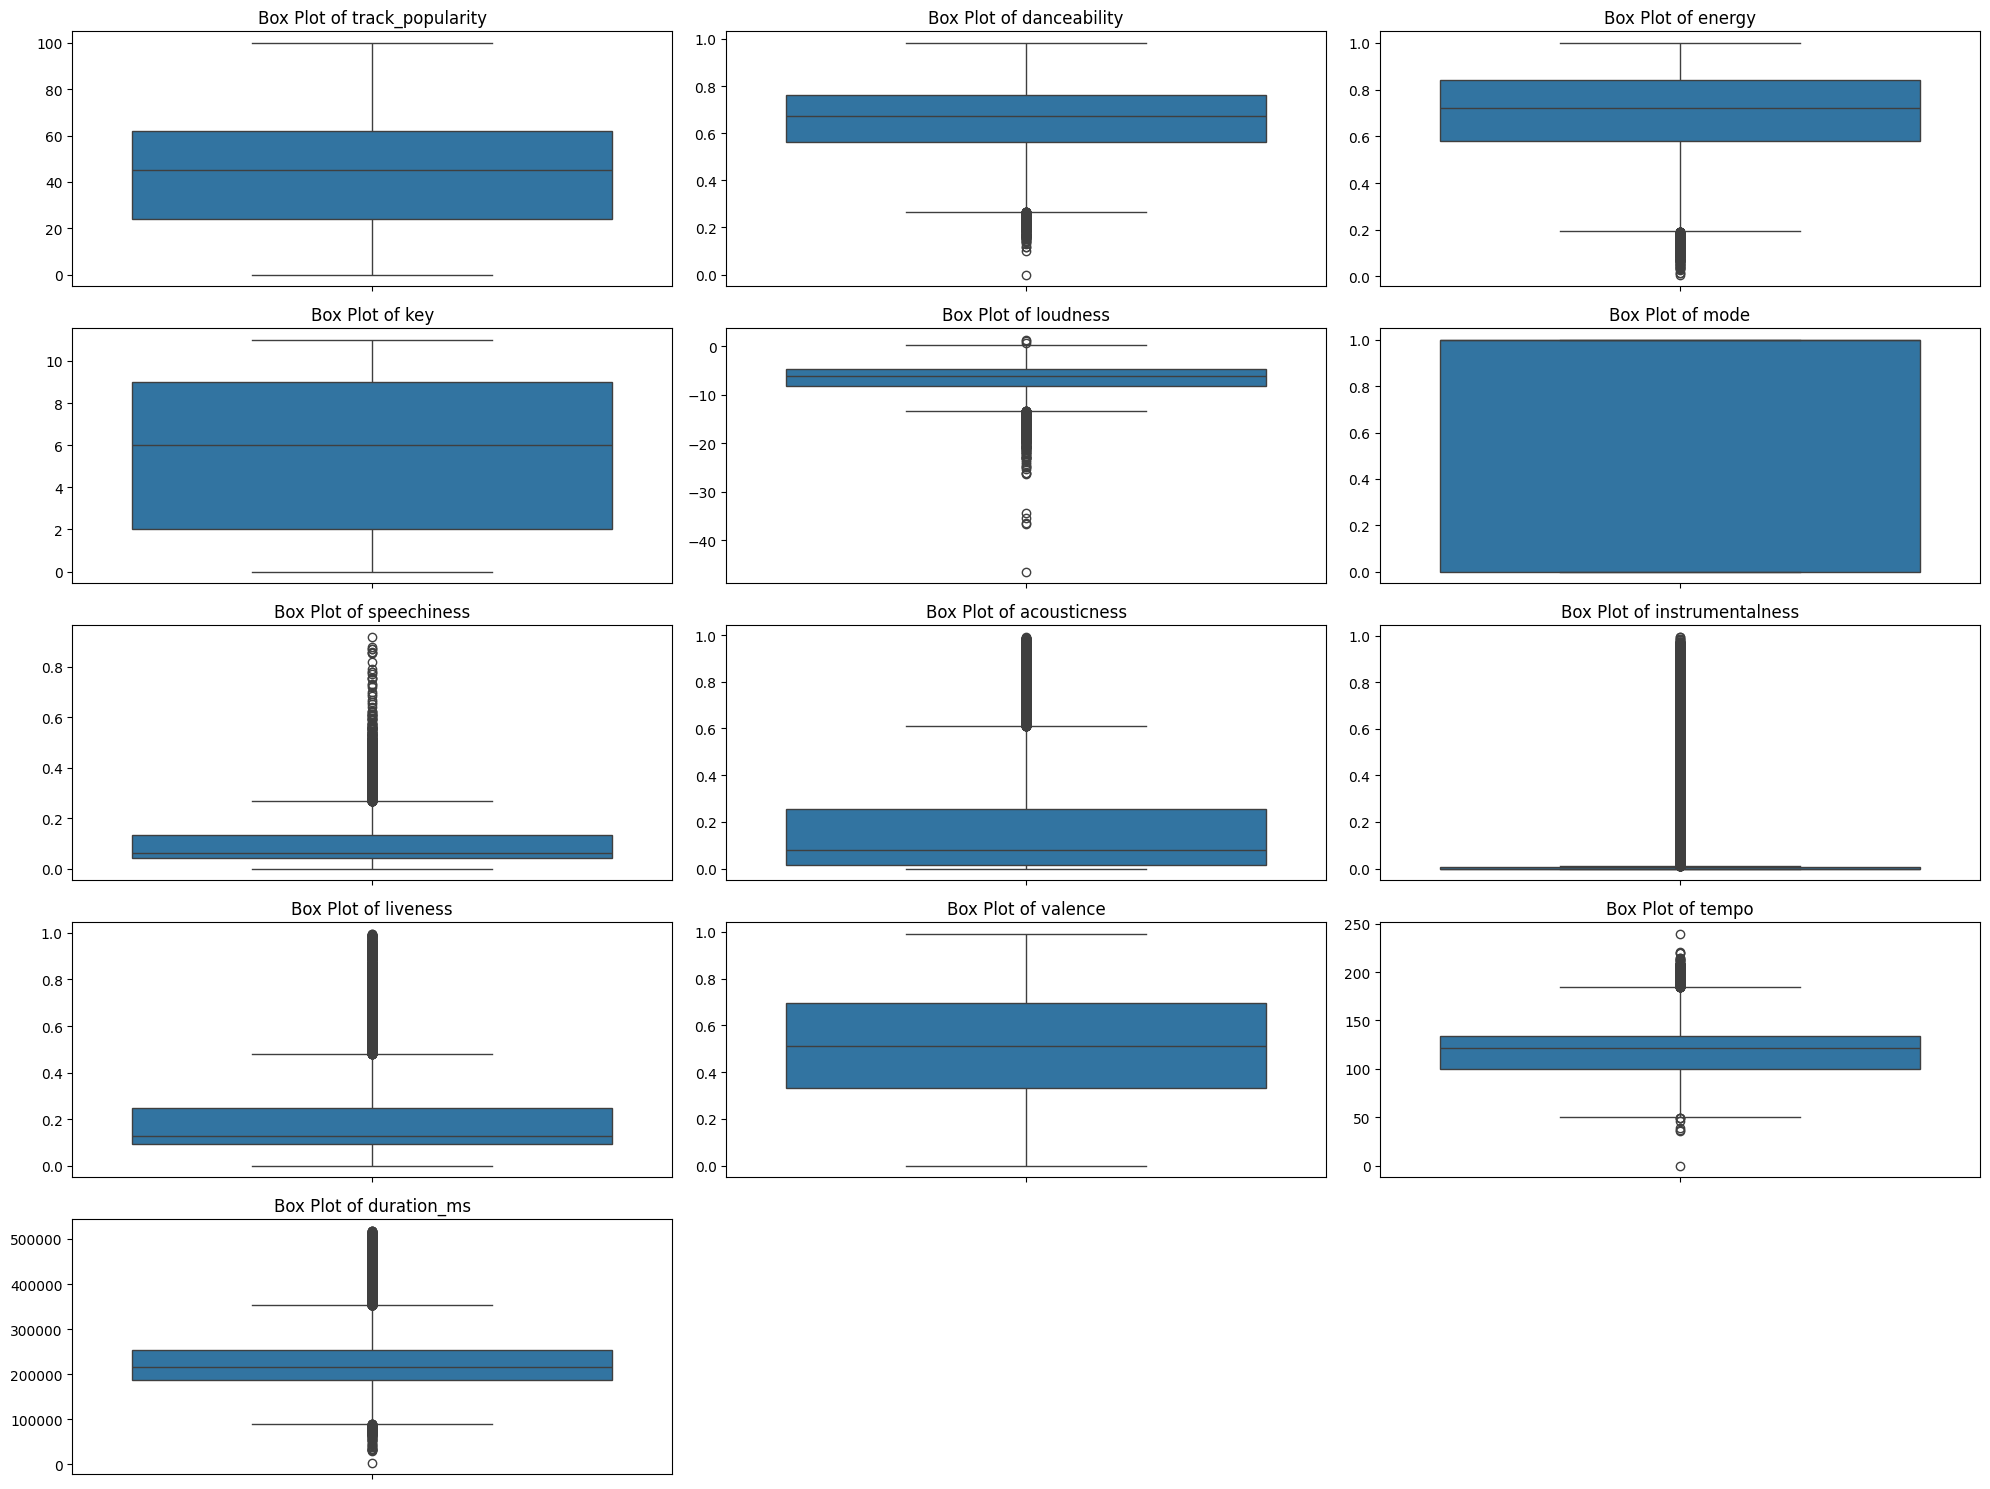

In [ ]:
plt.figure(figsize=(20,15))

for i, feature in enumerate(numerical_columns):
    plt.subplot(len(numerical_columns) // 3 + 1, 3, i + 1)
    sns.boxplot(data[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel('') # removing y-axis label to avoid clutter

plt.tight_layout()
plt.show()

In [ ]:
#number of unique values for each column
for feat in numerical_columns:
    num = data[feat].unique()
    print(f'no.uniques in {feat} = {len(num)}')

#based on the results most of the numerical columns is a continues variables

no.uniques in track_popularity = 101
no.uniques in danceability = 813
no.uniques in energy = 941
no.uniques in key = 12
no.uniques in loudness = 9525
no.uniques in mode = 2
no.uniques in speechiness = 1252
no.uniques in acousticness = 3572
no.uniques in instrumentalness = 4514
no.uniques in liveness = 1582
no.uniques in valence = 1309
no.uniques in tempo = 15205
no.uniques in duration_ms = 16967


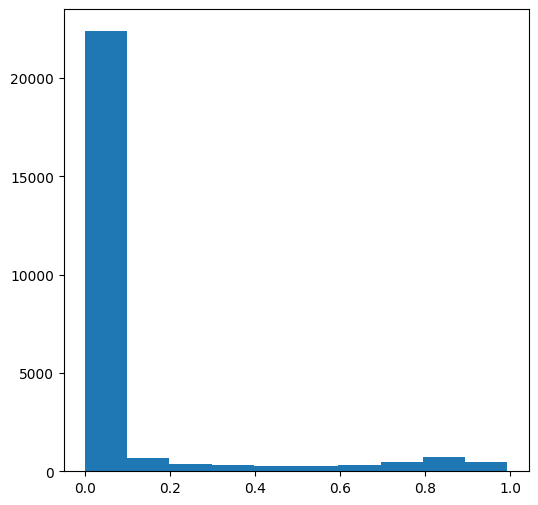

In [ ]:
#as the instumentanices is the most one that contians an outliers i will focus on it more
#to know whether it is a real outliers or it is the normal data
plt.figure(figsize= (6,6))
plt.hist(data['instrumentalness'])
plt.show() #based on the results it is a real data if i removed it i will lose very big amount of data
#so i will tend to solve it using normalization(scaling the features)

### ***Categorical coulmns***

In [ ]:
#asking myself what can drive a track to be popular ? (the playlist name, the artist , genre , subgenre )
#maybe the release date affects songs in 2025 are more heared than 2020 ones
#i need to convert -> datetime column
#encode all the categorical column to see the distributions
#handeling nulls
data['track_album_release_date'] = pd.to_datetime(data['track_album_release_date'] , format= '%m/%d/%Y' ,errors='coerce')

In [ ]:
data['track_album_release_date'].isna().sum()

np.int64(1526)

In [ ]:
data['track_album_release_date'] = data['track_album_release_date'].ffill()
print(f'no. Not a time values in the date column = {data['track_album_release_date'].isna().sum()}')

no. Not a time values in the date column = 0


In [ ]:
data['track_album_release_year'] = data['track_album_release_date'].dt.year
data['track_album_release_month'] = data['track_album_release_date'].dt.month
data['track_album_release_day'] = data['track_album_release_date'].dt.day

data.drop(columns =['track_album_release_date'] , axis = 1 , inplace = True)

In [ ]:
data.head()

,track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_album_release_year,track_album_release_month,track_album_release_day
0,Knock You Out - Hardwell Remix,Bingo Players,0,Knock You Out (Remixes),@deniceemoberg EDM - POP REMIXES,edm,pop edm,0.611,0.909,9,...,0.0493,0.0373,0.005010,0.0829,0.215,128.039,386279,2014,6,17
1,Insane in the Brain,Cypress Hill,70,Black Sunday,90's Hip Hop Ultimate Collection,rap,southern hip hop,0.897,0.612,11,...,0.2110,0.0297,0.186000,0.0894,0.767,102.305,208267,1993,7,20
2,Chill Cloud,Joan Ember,39,Chill Cloud,Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Po...,edm,pop edm,0.748,0.677,7,...,0.0688,0.1140,0.000000,0.2020,0.537,110.040,185466,2020,1,10
3,C90 (Remix),John C,78,C90 (Remix),Trapperz,rap,trap,0.867,0.761,1,...,0.0937,0.3360,0.000002,0.0654,0.609,122.952,316000,2019,12,18
4,Te Olvidaré,MYA,67,Te Olvidaré,Punto Tropical,latin,tropical,0.669,0.871,7,...,0.0671,0.0748,0.000000,0.3470,0.882,75.014,185415,2019,6,5


In [ ]:
#i want to see the seasonalities and trends in the data (like the time series analysis)
data.groupby('track_album_release_year').agg({
    'track_popularity':['count']
}
)

,track_popularity
,count
track_album_release_year,
1957,1
1958,1
1961,1
1963,2
1964,4
...,...
2016,1788
2017,2017


In [ ]:
for feat in categorical_columns:
    num = data[feat].unique()
    print(f'no.uniques in {feat} = {len(num)}')

no.uniques in track_name = 19602
no.uniques in track_artist = 9418
no.uniques in track_album_name = 16756
no.uniques in track_album_release_date = 4092
no.uniques in playlist_name = 449
no.uniques in playlist_genre = 6
no.uniques in playlist_subgenre = 24


In [ ]:
#Encoding
#for low_cardinality features
#One hot encoding is for the features with the small number of unique values like genre , sub genre
X= data.drop(columns=['track_popularity'])
y = data['track_popularity']
X_train,  y_train ,X_val , y_val = train_test_split(X , y , test_size=0.2 , random_state=42)

In [ ]:
#This is the first trial for combining all the steps on one pipline
def pre_processing(data):
    #exatracting the numerical and the categorical column
    numerical_columns = data.select_dtypes(include=['number']).columns.tolist()
    numerical_columnss =[]
    for feat in numerical_columns:
        if feat != 'track_popularity':
            numerical_columnss.append(feat)

    numerical_columns = numerical_columnss

    categorical_columns = ['track_name','track_artist','track_album_name','playlist_name','playlist_genre',
                           'playlist_subgenre', ]


    #dropping unnecessary columns
    data.drop(columns=['id' , 'track_id' , 'track_album_id' , 'playlist_id'] , inplace = True)

    #converting to datetime data type
    data['track_album_release_date'] = pd.to_datetime(data['track_album_release_date'] , format= '%m/%d/%Y' ,errors='coerce')
    #filling null dates
    data['track_album_release_date'] = data['track_album_release_date'].ffill()
    #converting to year , month , day
    data['track_release_year'] = data['track_album_release_date'].dt.year
    data['track_release_month'] = data['track_album_release_date'].dt.month
    data['track_release_day'] = data['track_album_release_date'].dt.day
    data.drop(columns=['track_release_date']  , axis = 1 , inplace = True )


    #Normalization(using standard scaler)
    data[numerical_columns] = StandardScaler().fit_transform(data[numerical_columns])

    #Label encoding
    for col in categorical_columns:
        if col in data.columns :
            data[col] = data[col].fillna('Unknown')
            data[col] = LabelEncoder().fit_transform(data[col].astype(str))

    return data



#it caused an error so i will be right back latter

# ***Completed pipeline***

In [ ]:
def pre_processing(data, fit_encoders=True, numerical_encoders=None, categorical_encoders=None):
    data = data.copy()

    # dropping unesseccary columns
    data.drop(columns=['id', 'track_id', 'track_album_id', 'playlist_id'], inplace=True, errors='ignore')

    #converting and extracting datetime features
    data['track_album_release_date'] = pd.to_datetime(data['track_album_release_date'], format='%m/%d/%Y', errors='coerce')
    data['track_album_release_date'] = data['track_album_release_date'].ffill()#propagating and forward fill

    # extracting useful features
    data['track_release_year'] = data['track_album_release_date'].dt.year
    data['track_release_month'] = data['track_album_release_date'].dt.month
    data['track_release_day'] = data['track_album_release_date'].dt.day

    # dropping the column as i don't want it for now
    data.drop(columns=['track_album_release_date'] , inplace=True)

    #identify features (AFTER all modifications) that caused a problem with me that i made it before modification
    numerical_columns = data.select_dtypes(include=['number']).columns.tolist()

    # Removing target from numerical columns if it exists
    if 'track_popularity' in numerical_columns:
        numerical_columns.remove('track_popularity')

    categorical_columns = ['track_name', 'track_artist', 'track_album_name',
                          'playlist_name', 'playlist_genre', 'playlist_subgenre']

    # Initialize encoders if not provided
    if numerical_encoders is None:
        numerical_encoders = StandardScaler()
    if categorical_encoders is None:
        categorical_encoders = {col: LabelEncoder() for col in categorical_columns}

    # Normalizing numerical features
    if numerical_columns:
        if fit_encoders:
            data[numerical_columns] = numerical_encoders.fit_transform(data[numerical_columns])
        else:
            data[numerical_columns] = numerical_encoders.transform(data[numerical_columns])

    # Label encoding for categorical features
    for col in categorical_columns:
        if col in data.columns:
            data[col] = data[col].fillna('Unknown')

            if fit_encoders:
                data[col] = categorical_encoders[col].fit_transform(data[col].astype(str))
            else:
                # transform for the testing data
                try:
                    data[col] = categorical_encoders[col].transform(data[col].astype(str))
                except ValueError:
                    data[col] = data[col].median()

    return data, numerical_encoders, categorical_encoders

In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/FCDS/Deep learning/songs_train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/FCDS/Deep learning/songs_test.csv')

In [ ]:
# for training data
train_data_processed, numerical_encoders, categorical_encoders = pre_processing(
    train_data,
    fit_encoders=True
)

# for the test Data (using the same encoders)
test_data_processed, _, _ = pre_processing(
    test_data,
    fit_encoders=False,
    numerical_encoders=numerical_encoders,
    categorical_encoders=categorical_encoders
)

TypeError: Cannot convert ['Every Little Step' 'Cúrame (feat. Manuel Turizo)' 'Never Change' ...
 'Stay Young' 'Ruthless For Life' "What's My Name?"] to numeric

In [ ]:
train_data_processed.head()

,track_name,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_release_year,track_release_month,track_release_day
0,8824,970,0,7487,29,0,16,-0.302573,1.160081,1.004771,...,-0.571746,-0.627283,-0.358285,-0.693347,-1.268283,0.263509,2.671713,0.170518,-0.124683,0.285352
1,8163,1819,70,1821,19,4,20,1.661489,-0.477683,1.558129,...,1.028487,-0.661836,0.444147,-0.651123,1.097079,-0.693092,-0.293614,-1.854315,0.143930,0.603532
2,2904,3970,39,2671,63,0,16,0.638254,-0.119249,0.451413,...,-0.378768,-0.278568,-0.380498,0.080336,0.111511,-0.405562,-0.673433,0.749042,-1.467751,-0.457069
3,2428,4004,78,2290,388,4,21,1.455468,0.343956,-1.208662,...,-0.132350,0.730751,-0.380488,-0.807029,0.420037,0.074412,1.501004,0.652622,1.486998,0.391412
4,16027,5149,67,13479,300,1,22,0.095734,0.950536,0.451413,...,-0.395592,-0.456790,-0.380498,1.022268,1.589863,-1.707572,-0.674283,0.652622,-0.124683,-0.987369


In [ ]:
test_data_processed

,track_name,track_artist,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_release_year,track_release_month,track_release_day
0,-1,-1,-1,77,5,2,0.926682,-0.251594,-1.208662,-1.608010,...,-0.666751,-0.764268,-0.380498,-0.981124,1.838397,-0.785244,0.189019,-2.336418,-1.467751,-1.411610
1,-1,-1,-1,113,1,19,0.706927,-0.383939,1.281450,0.381537,...,-0.216469,1.308153,-0.380490,-0.497815,0.274344,-0.890070,-0.365976,0.652622,-0.124683,-0.775249
2,-1,-1,-1,251,3,13,-1.744715,-0.058592,1.281450,0.178289,...,1.137347,0.812587,-0.380498,-0.426358,0.488598,-1.077495,0.080858,-0.600847,-0.930524,0.709592
3,-1,-1,-1,308,4,6,0.638254,-1.404094,1.558129,-0.678303,...,-0.585601,0.098790,-0.380323,-0.400374,-1.975749,0.338152,-1.429740,0.556201,0.143930,-1.305550
4,-1,-1,-1,150,4,6,0.157540,0.525930,1.281450,0.177954,...,0.325849,0.448869,-0.380490,-0.426358,0.124367,-1.248118,1.077441,0.556201,0.143930,-1.305550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6562,-1,-1,-1,110,2,5,-0.446787,0.553502,1.281450,0.038095,...,-0.714253,0.026046,-0.380481,0.138801,-0.792639,-0.481134,0.451549,-1.275791,-1.467751,-1.411610
6563,-1,-1,-1,171,5,7,-2.115552,0.972593,-0.931983,-0.429442,...,-0.610342,-0.795166,-0.380475,0.814394,-0.132738,1.750416,0.916375,0.652622,1.218384,-1.093429
6564,-1,-1,-1,138,0,18,-0.570399,0.079267,-0.101946,0.634087,...,-0.657844,-0.454062,-0.380498,0.236242,0.205783,-1.150651,-1.147537,0.459780,0.681157,-1.411610
6565,-1,-1,-1,150,4,6,0.844274,0.928478,-1.208662,0.043797,...,1.473821,-0.019418,-0.380498,-0.387382,0.154362,-0.965457,0.643666,-1.372212,-0.124683,1.664133


### ***i still have a problem that i want to make a one hot encoding for the genre and sub genre***

In [ ]:
#Splitting into X , y for training the test data is just for submitting the predictions
X = train_data_processed.drop(columns=['track_popularity'] , axis = 1)
y = train_data['track_popularity']

In [ ]:
print (f'the features shape {X.shape}')
print (f'the target shape {y.shape}')

the features shape (26266, 21)
the target shape (26266,)


In [ ]:
X_train , X_val , y_train , y_val = train_test_split(X , y, test_size = 0.15  , random_state=42)

In [ ]:
print (f'the X_train shape {X_train.shape}')
print (f'the y_train shape {y_train.shape}')
print (f'the X_val shape {X_val.shape}')
print (f'the y_val shape {y_val.shape}')

the X_train shape (22326, 21)
the y_train shape (22326,)
the X_val shape (3940, 21)
the y_val shape (3940,)


# ***Model Building***

In [ ]:
#now building the model using tensotrflow
import tensorflow as tf
from tensorflow.keras import layers , models , Sequential ,optimizers

In [ ]:
input_shape = [X_train.shape[1]]

model1 = Sequential(
    [
        layers.Dense(128, activation = 'linear' , input_shape= input_shape ),
        layers.Dense(64, activation = 'relu'),
        layers.Dense(32, activation = 'relu'),
        layers.Dense(1)
    ]
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = optimizers.Adam(learning_rate = 0.001)
model1.compile(optimizer = optimizer , loss = 'mse')
history1 = model1.fit(
    X_train ,
    y_train ,
    validation_data= (X_val , y_val),
    batch_size = 256,
    epochs = 50
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 64523.6016 - val_loss: 1090.9901
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 980.0819 - val_loss: 850.9753
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 849.0640 - val_loss: 802.5687
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 814.7440 - val_loss: 790.5026
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 802.1280 - val_loss: 787.0760
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 776.9956 - val_loss: 749.5958
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 786.3644 - val_loss: 758.2999
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 748.6804 - val_loss: 739.4114
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 747.9594 - val_loss: 794.4350
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 772.7376 - val_loss: 721.0990
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 818.0005 - val_loss: 725.7204
Epoch 12/50
88/88 ━━━━━━━━

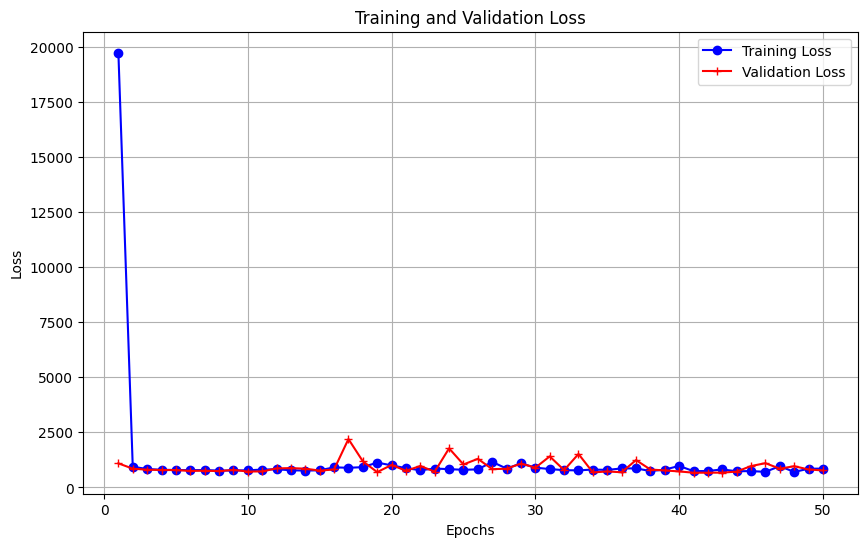

In [ ]:
import matplotlib.pyplot as plt

# Extract the loss data
training_loss = history1.history['loss']
validation_loss = history1.history['val_loss']
epochs = range(1, len(training_loss) + 1)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the training loss
plt.plot(epochs, training_loss, 'bo-', label='Training Loss')

# Plot the validation loss
plt.plot(epochs, validation_loss, 'r+-', label='Validation Loss')

# Add titles and labels
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Add a legend to distinguish the lines
plt.legend()

# Add a grid for better readability
plt.grid(True)

# Display the plot
plt.show()


# ***changing the model itself and using the batch norm***

In [ ]:
model = Sequential(
    [
    layers.Dense(256 , activation = 'linear' , input_shape = input_shape),

    layers.BatchNormalization(),
    layers.Dense(128 , activation = 'relu'),

    layers.BatchNormalization(),
    layers.Dense(64, activation = 'relu'),

    layers.BatchNormalization(),
    layers.Dense(32 , activation = 'relu'),

    layers.BatchNormalization(),
    layers.Dense(16 , activation = 'relu'),

    layers.Dense(1)
    ]
)

model.compile(optimizer = optimizers.Adam(learning_rate = 0.001) , loss = 'mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,329 (200.50 KB)

 Trainable params: 50,369 (196.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    X_train ,
    y_train ,
    validation_data = (X_val , y_val),
    batch_size = 300,
    epochs =20,
)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 2205.9417 - val_loss: 1926.4957
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1706.4155 - val_loss: 1439.0820
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1136.1731 - val_loss: 776.5859
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 718.4748 - val_loss: 697.8776
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 653.6804 - val_loss: 645.2778
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 640.4609 - val_loss: 647.8804
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 628.2342 - val_loss: 632.1118
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 628.1396 - val_loss: 637.2260
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 625.8494 - val_loss: 628.7744
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 628.3010 - val_loss: 630.9537
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 614.4800 - val_loss: 631.5289
Epoch 12/20
75/75 ━━━━━━

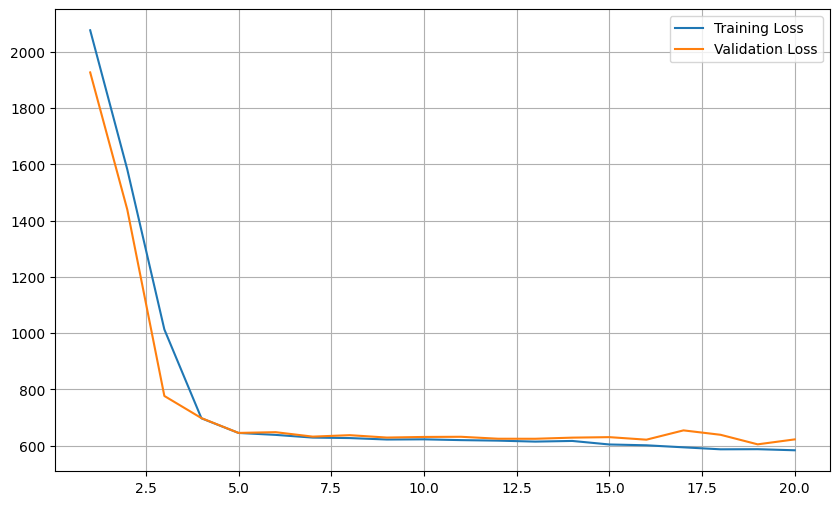

In [ ]:
train_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize = (10, 6))
plt.plot(epochs ,train_loss , label = 'Training Loss')
plt.plot(epochs , validation_loss , label = 'Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions = model.predict(test_data_processed)
to_submit = test_data['id']

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
predictions = predictions.flatten()

In [ ]:
to_submit

,id
0,0
1,1
2,2
3,3
4,4
...,...
6562,6562
6563,6563
6564,6564
6565,6565


In [ ]:
data_final = pd.DataFrame(
    {
    'id' : to_submit,
    'track_popularity' : predictions
    })

data_final.to_csv('submissions2.csv' , index = False)


,IDs,track_popularity
0,0,49.798012
1,1,52.667278
2,2,52.850899
3,3,53.732536
4,4,51.364105
